# Análisis no supervisado en el dataset Spotify

* Objetivo

El objetivo de este notebook es el de encontrar patrones o grupos ocultos utilizando herramientas de clustering para luego realizar análisis de estos hallazgos para los futuros modelos de ML.

En esta etapa se realizan las siguientes operaciones:

* Matriz de correlación
* PCA

In [4]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [2]:
data = pd.read_csv("../dataset/spotify_train_preprocesado.csv")

df = data.copy()

df.head()

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


# 1ra pregunta: ¿Qué perfiles o tipos de canciones se pueden identificar según sus características musicales?

Primero, se realizará un chequeo de las correlaciones para lograr identificar si existen correlaciones fuertes en el dataset en base a las características de las canciones.

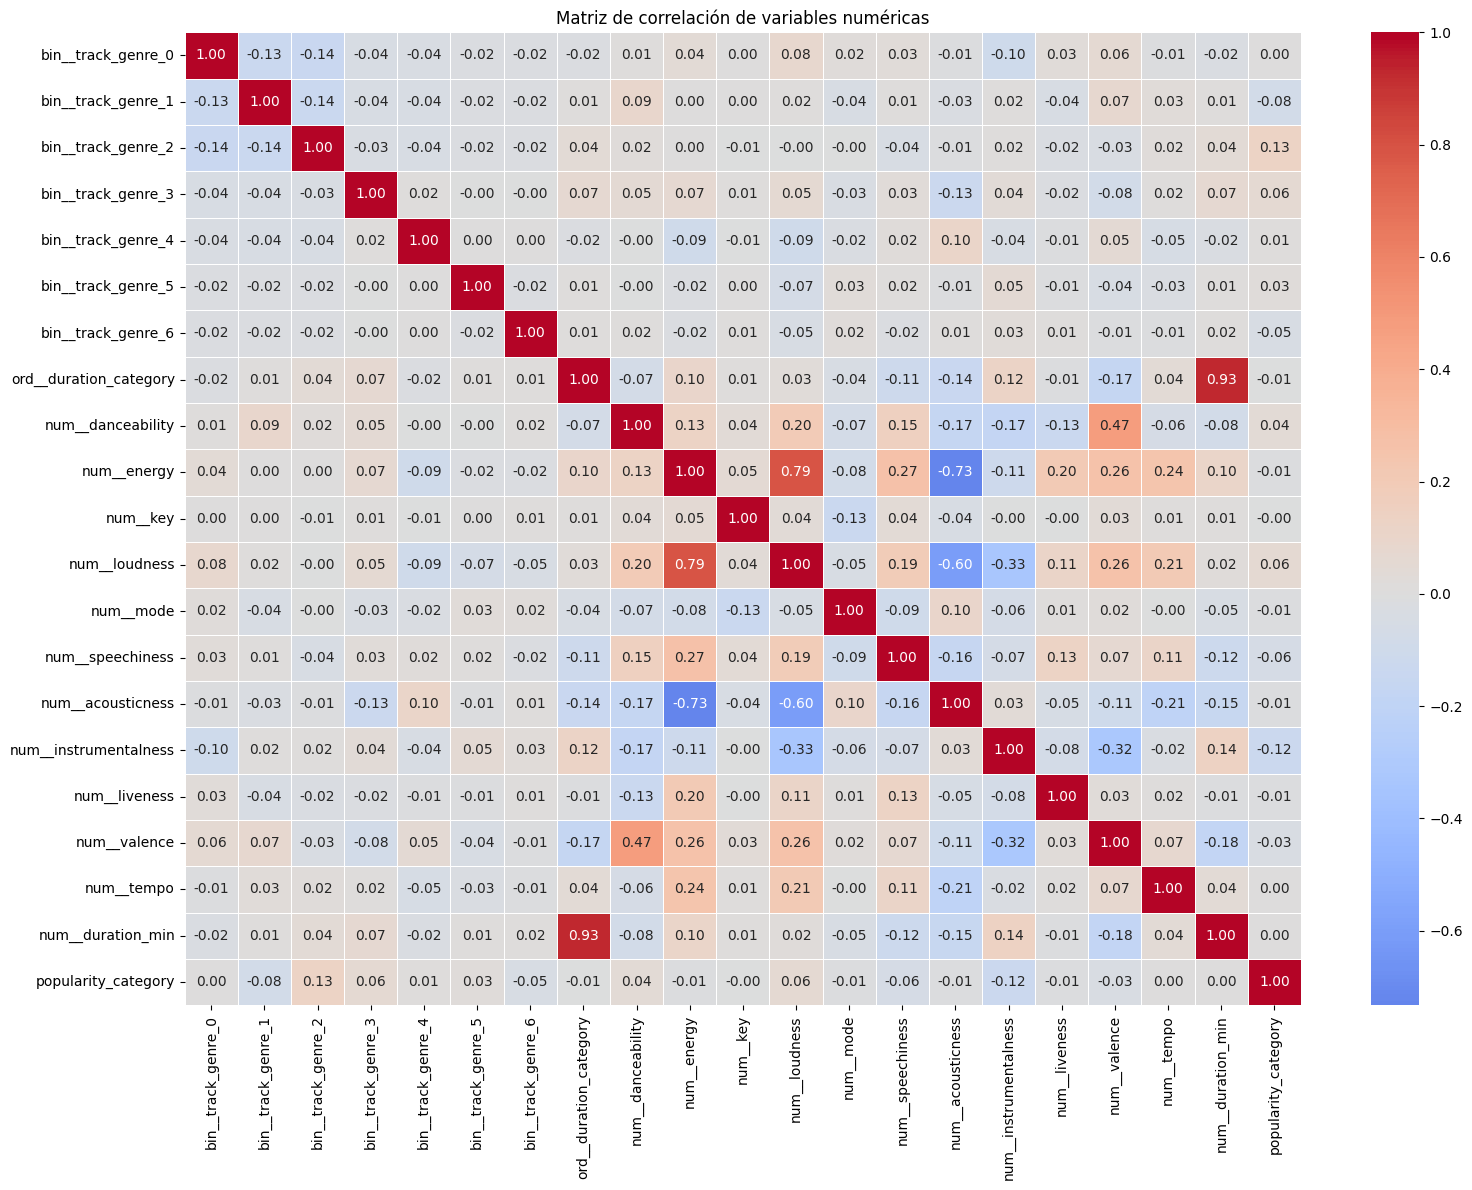

In [3]:
# Calcular matriz de correlación
matriz_correlacion = df.corr()

# Visualizar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

---

# PCA en el dataset

Con el fin de entender la importancia de las variables del dataset y reducir la dimensionalidad, se utiliza la herramienta PCA para identificar la varianza explicada por cada componente individual y la acumulada del PCA.

In [5]:
features_pca = [
    "bin__track_genre_0",
    "bin__track_genre_1",
    "bin__track_genre_2",
    "bin__track_genre_3",
    "bin__track_genre_4",
    "bin__track_genre_5",
    "bin__track_genre_6",
    "ord__duration_category",
    "num__danceability",
    "num__energy",
    "num__key",
    "num__loudness",
    "num__mode",
    "num__speechiness",
    "num__acousticness",
    "num__instrumentalness",
    "num__liveness",
    "num__valence",
    "num__tempo",
    "num__duration_min"
]

X_pca = df[features_pca]

In [6]:
pca = PCA()

X_pca_transformed = pca.fit_transform(X_pca)

In [7]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (individual, cumulative) in enumerate(
    zip(explained_variance, cumulative_variance),
    start=1
):
    print(
        f"PC{i}: "
        f"{individual:.2%} individual | "
        f"{cumulative:.2%} acumulada"
    )

PC1: 19.70% individual | 19.70% acumulada
PC2: 14.80% individual | 34.50% acumulada
PC3: 9.03% individual | 43.53% acumulada
PC4: 8.04% individual | 51.57% acumulada
PC5: 6.95% individual | 58.52% acumulada
PC6: 6.36% individual | 64.89% acumulada
PC7: 6.00% individual | 70.89% acumulada
PC8: 5.55% individual | 76.43% acumulada
PC9: 5.15% individual | 81.59% acumulada
PC10: 3.19% individual | 84.78% acumulada
PC11: 2.28% individual | 87.06% acumulada
PC12: 1.89% individual | 88.95% acumulada
PC13: 1.85% individual | 90.81% acumulada
PC14: 1.74% individual | 92.55% acumulada
PC15: 1.71% individual | 94.25% acumulada
PC16: 1.64% individual | 95.89% acumulada
PC17: 1.55% individual | 97.44% acumulada
PC18: 1.16% individual | 98.59% acumulada
PC19: 0.93% individual | 99.53% acumulada
PC20: 0.47% individual | 100.00% acumulada


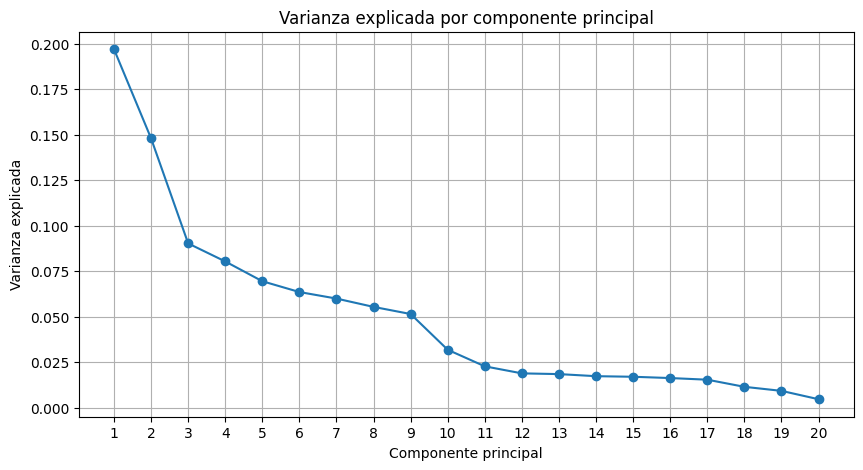

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada por componente principal")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)

plt.show()

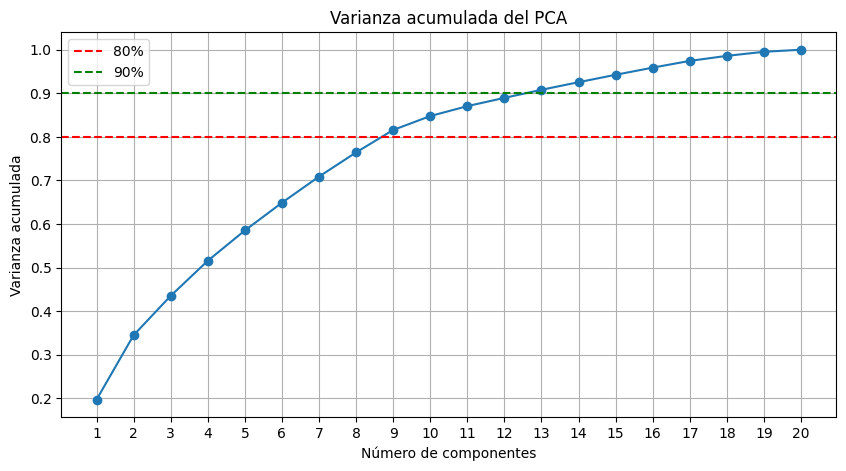

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.80,
    color="red",
    linestyle="--",
    label="80%"
)

plt.axhline(
    0.90,
    color="green",
    linestyle="--",
    label="90%"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada del PCA")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)

plt.show()